In [2]:
import argparse
import copy
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from dataset.CremadDataset import CremadDataset
from models.basic_model import AClassifier,VClassifier
from utils.utils import setup_seed, weight_init
import time
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

In [3]:
def get_arguments():
    parser = argparse.ArgumentParser()
    parser.add_argument('--dataset', default='CREMAD', type=str,
                        help='VGGSound, KineticSound, CREMAD, AVE')
    parser.add_argument('--batch_size', default=64, type=int)
    parser.add_argument('--epochs', default=150, type=int)
    parser.add_argument('--embed_dim', default=512, type=int)
    parser.add_argument('--optimizer', default='SGD', type=str)
    parser.add_argument('--learning_rate', default=0.001, type=float, help='initial learning rate')
    parser.add_argument('--ckpt_path', default='ckpt', type=str, help='path to save trained models')
    parser.add_argument('--train', action='store_true', help='turn on train mode')
    parser.add_argument('--random_seed', default=0, type=int)
    parser.add_argument('--gpu', type=int, default=0)  # gpu
    parser.add_argument('--no_cuda', action='store_true', help='Disable CUDA')
    return parser.parse_args(args=[])

In [4]:
args = get_arguments()

In [5]:
train_dataset = CremadDataset(args, mode='train')
test_dataset = CremadDataset(args, mode='test')

In [6]:
train_dataloader = DataLoader(train_dataset, batch_size=64,shuffle=True,num_workers=10)
test_dataloader = DataLoader(test_dataset, batch_size=64,num_workers=10)

In [7]:
device = torch.device('cuda')

In [8]:
# w/o KD
model1 = AClassifier(args)
model2 = VClassifier(args)
model1.to(device)
model2.to(device)
model1.load_state_dict(torch.load('./ckpt/unimodality-audio/model-CREMAD-frm1-bsz64-lr0.01/best.pt')['model'])
model2.load_state_dict(torch.load('./ckpt/unimodality-visual/model-CREMAD-frm1-bsz64-lr0.01/best.pt')['model'])

#Ours
model3 = AClassifier(args)
model4 = VClassifier(args)
model3.to(device)
model4.to(device)
model3.load_state_dict(torch.load('./ckpt/FD_CMKD/model-CREMAD-bsz64-lr0.01-epoch100/best_a.pt',map_location=device)['model']) 
model4.load_state_dict(torch.load('./ckpt/FD_CMKD/model-CREMAD-bsz64-lr0.01-epoch100/best_v.pt',map_location=device)['model']) 

#Feat KD
model5 = AClassifier(args)
model6 = VClassifier(args)
model5.to(device)
model6.to(device)
model5.load_state_dict(torch.load('./ckpt/CM_feat/model-CREMAD-concat-bsz64-lr0.01-epoch100-1-optim-SGD/best_a.pt',map_location=device)['model']) 
model6.load_state_dict(torch.load('./ckpt/CM_feat/model-CREMAD-concat-bsz64-lr0.01-epoch100-1-optim-SGD/best_v.pt',map_location=device)['model']) 

/tmp/ipykernel_39/3517778807.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load('../CKD-CREMAD/ckpt/unimodality-audio/model-CREMAD-frm1-bs

<All keys matched successfully>

In [9]:
test_dataloader = DataLoader(test_dataset, batch_size=1)

import tqdm
all_a = []
all_a0 = []
all_a1 = []
all_a2 = []
all_a3 = []
all_a4 = []
all_v = []
all_v0 = []
all_v1 = []
all_v2 = []
all_v3 = []
all_v4 = []
all_labels = []
with torch.no_grad():
    model1.eval()
    model2.eval()
    model3.eval()
    model4.eval()
    model5.eval()
    model6.eval()
    # model7.eval()
    # model8.eval()
 
    for step, (spec, image, label) in enumerate(tqdm.tqdm(test_dataloader)):
    # for step, (spec, image, label) in enumerate(tqdm.tqdm(train_dataloader)):
        spec = spec.to(device)
        image = image.to(device)
        label = label.to(device)
        B = label.shape[0]

        a1,out1 = model1(spec.unsqueeze(1).float())
        v1,out2 = model2(image.float(), B)
        a2,out1 = model3(spec.unsqueeze(1).float())
        v2,out2 = model4(image.float(), B)
        a3,out1 = model5(spec.unsqueeze(1).float())
        v3,out2 = model6(image.float(), B)
        # a4,out1 = model7(spec.unsqueeze(1).float())
        # v4,out2 = model8(image.float(), B)
        # a2,out1 = model3(spec.unsqueeze(1).float())
        # v2,out2 = model4(image.float(), B)

        all_a1.append(a1)
        all_a2.append(a2)
        all_v1.append(v1)
        all_v2.append(v2)
        all_a3.append(a3)
        # all_a4.append(a4)
        all_v3.append(v3)
        # all_v4.append(v4)
        
        # all_a0.append(a)
        # all_v0.append(v)
        all_labels.append(label)

100%|██████████| 744/744 [00:47<00:00, 15.81it/s]


## Without KD

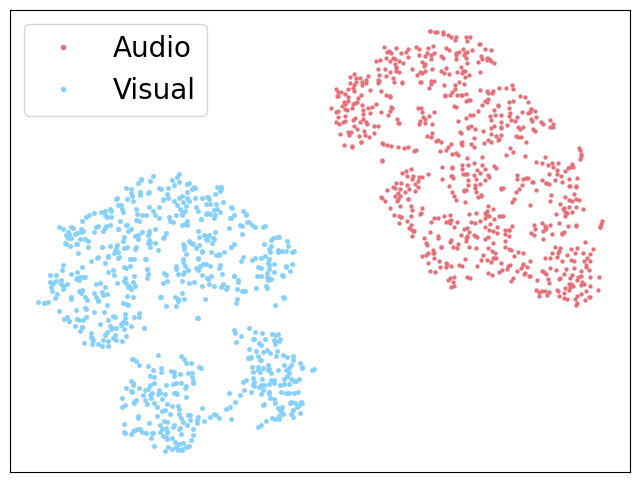

In [33]:
features = torch.concat([torch.cat(all_a1),torch.cat(all_v1)]).cpu().numpy()

tsne = TSNE(n_components=2)
embedded = tsne.fit_transform(features)

colors = ['#e47178','#85d0ff']
legend_elements = [
                   Line2D([0], [0], marker='.', color='w', label='Audio',
                          markerfacecolor=colors[0], markersize=10),
                  Line2D([0], [0], marker='.', color='w', label='Visual',
                          markerfacecolor=colors[1], markersize=10)]
# 可视化展示
plt.figure(figsize=(8, 6))

for step, (spec, image, label) in enumerate(test_dataloader):
    plt.scatter(embedded[step, 0], embedded[step, 1], marker='.', linewidths=0.1, color=colors[0])
    plt.scatter(embedded[step+744, 0], embedded[step+744, 1], marker='.', linewidths=0.5, color=colors[1])

# Remove ticks and tick labels
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.legend(handles=legend_elements,fontsize=20)
plt.show()

## Feat KD

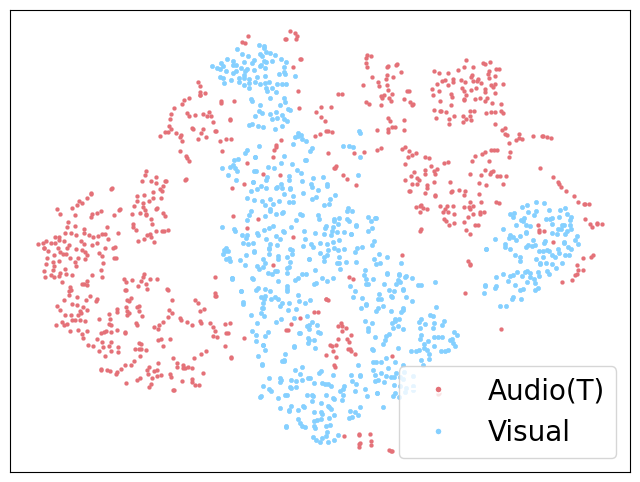

In [37]:
features = torch.concat([torch.cat(all_a1),torch.cat(all_v3)]).cpu().numpy()

tsne = TSNE(n_components=2)
embedded = tsne.fit_transform(features)

colors = ['#e47178','#85d0ff']
legend_elements = [
                   Line2D([0], [0], marker='.', color='w', label='Audio(T)',
                          markerfacecolor=colors[0], markersize=10),
                  Line2D([0], [0], marker='.', color='w', label='Visual',
                          markerfacecolor=colors[1], markersize=10)]
# 可视化展示
plt.figure(figsize=(8, 6))

for step, (spec, image, label) in enumerate(test_dataloader):
    plt.scatter(embedded[step, 0], embedded[step, 1], marker='.', linewidths=0.1, color=colors[0])
    plt.scatter(embedded[step+744, 0], embedded[step+744, 1], marker='.', linewidths=0.5, color=colors[1])

# Remove ticks and tick labels
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.legend(handles=legend_elements,fontsize=20)
plt.show()

## Ours

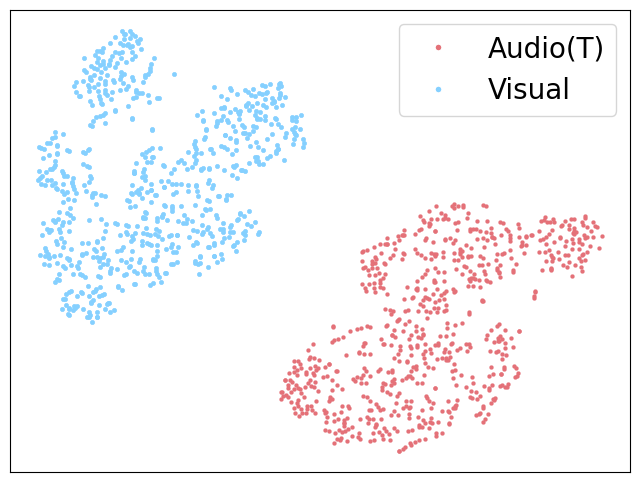

In [11]:
features = torch.concat([torch.cat(all_a1),torch.cat(all_v2)]).cpu().numpy()

tsne = TSNE(n_components=2)
embedded = tsne.fit_transform(features)

colors = ['#e47178','#85d0ff']
legend_elements = [
                   Line2D([0], [0], marker='.', color='w', label='Audio(T)',
                          markerfacecolor=colors[0], markersize=10),
                  Line2D([0], [0], marker='.', color='w', label='Visual',
                          markerfacecolor=colors[1], markersize=10)]
# 可视化展示
plt.figure(figsize=(8, 6))

for step, (spec, image, label) in enumerate(test_dataloader):
    plt.scatter(embedded[step, 0], embedded[step, 1], marker='.', linewidths=0.1, color=colors[0])
    plt.scatter(embedded[step+744, 0], embedded[step+744, 1], marker='.', linewidths=0.5, color=colors[1])

# Remove ticks and tick labels
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.legend(handles=legend_elements,fontsize=20)
plt.show()